# Task 1: Introduction

In [200]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

# Task 2: Dataset

Real estate agent table:

|Area|Distance|Price|
|---|---|---|
|70|3|21200|
|50|1|22010|
|120|9|24305|
|100|2|31500|

You can write the relationship with a 2-variable linear equation:

$
\begin{equation}
y = b + w_1.x_1 + w_2.x_2
\end{equation}
$

In a vector form:

$
\begin{equation}
y = b + (w_1 w_2).\binom{x_1}{x_2}
\end{equation}
$

Where
$
\begin{equation}
W = (w_1 w_2)
\end{equation}
$
and
$
\begin{equation}
X = \binom{x_1}{x_2}
\end{equation}
$

In [201]:
def generate_exampeles(num=1000):
    W= [1.0, -3.0]
    b= 1.0
    
    W = np.reshape(W, (2, 1))
    
    X = np.random.randn(num, 2)
    
    y = b + np.dot(X, W) + np.random.randn() #added noise
    
    y = np.reshape(y, (num, 1))
    
    return X, y

In [202]:
X, y = generate_exampeles()

In [203]:
print(X.shape, y.shape)

(1000, 2) (1000, 1)


In [204]:
print(X[0], y[0])

[0.15748046 0.07947229] [2.1445469]


# Task 3: Initialize Parameters

The loss over **m** examples:

$
\begin{equation}
J = \frac{1}{2m} \sum_{i=1}^{m} (y - \hat{y})^2
\end{equation}
$

The objective of the gradient descent algorithm is to minimize this loss value.

Gradient Descent Objective is to 
$
\begin{equation}
min(J)
\end{equation}
$

In [205]:
class Model:
    def __init__(self, num_features):
        self.num_features = num_features
        self.W = np.random.randn(num_features, 1)
        self.b = np.random.randn()

In [206]:
model = Model(2)
print(model.W)
print(model.b)

[[-1.80901602]
 [ 1.24718274]]
-0.44073444670132894


# Task 4: Forward Pass

The gradient descent algorithm can be simplified in 4 steps:

1. Get predictions y_hat for X with current values of W and b.
2. Compute the loss between y and y_hat
3. Find gradients of the loss with respect to parameters W and b
4. Update the values of W and b by subtracting the gradient values obtained in the previous step

Let's simplify our linear equation a bit more for an example:
$
\begin{equation}
y = wx
\end{equation}
$

Let's plot J as a function of w

![Loss vs Param](JvsW.png)

The gradients of loss with respect to w:

\begin{equation}
\frac{dJ}{dw} = \frac{\delta{J}}{\delta{w}} = \lim_{\epsilon \to 0} \frac{J(w + \epsilon) - J(w)}{\epsilon}
\end{equation}

In [207]:
 class Model(Model):
        def forward_pass(self, X):
            y_hat = self.b + np.dot(X, self.W)
            return y_hat

In [208]:
y_hat = Model(2).forward_pass(X)
print(y_hat.shape, y_hat[0])

(1000, 1) [-0.92227407]


# Task 5: Compute Loss

The loss over **m** examples:

$
\begin{equation}
J = \frac{1}{2m} \sum_{i=1}^{m} (y - \hat{y})^2
\end{equation}
$

In [209]:
class Model(Model):
    def compute_loss(self, y_hat, y_true):
       return np.sum(np.square(y_hat - y_true))/(2*y_hat.shape[0])

model = Model(2)

In [210]:
model=Model(2)
y_hat=model.forward_pass(X)
loss=model.compute_loss(y_hat, y)

In [211]:
loss

10.074781902583435

# Task 6: Backward Pass

The gradient of loss with respect to bias can be calculated with:

$
\begin{equation}
\frac{dJ}{db} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y^{(i)}} - y^{(i)})
\end{equation}
$

$
\begin{equation}
\frac{dJ}{dW_j} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y^{(i)}} - y^{(i)}).x_j^{(i)}
\end{equation}
$

In [212]:
class Model(Model):
    def backward_pass(self, X, y_true, y_hat):
        m = y_true.shape[0]
        db= (1/m)*np.sum(y_hat - y_true)
        dw = (1/m)*np.sum(np.dot(np.transpose(y_hat - y_true), X), axis=0)
        return dw, db
    

In [213]:
model = Model(2)

X, y = generate_exampeles()
y_hat = model.forward_pass(X)

dw, db = model.backward_pass(X, y, y_hat)

In [214]:
print(dw, db)

[-0.41009234  2.02335976] -0.5683542891591679


# Task 7: Update Parameters

In [215]:
class Model(Model):
    def update_params(self, dW, db, lr):
        self.W = self.W - lr * np.reshape(dW, (self.num_features, 1))
        #can also write it this way
        #self.W = self.W - lr * np.reshape(dW, self.W.Shape)
        self.b = self.b - db    #don't need to change shape bec. scaler

# Task 8: Training Loop

In [216]:
class Model(Model):
    def train(self, x_train, y_train, iterations, lr):
        losses = []
        for i in range(0,iterations):
            y_hat = self.forward_pass(x_train)
            loss = self.compute_loss(y_hat, y_train)   #mean squared error(mse)
            dW, db = self.backward_pass(x_train, y_train, y_hat)
            self.update_params(dW, db, lr)
            losses.append(loss)
            if i%int(iterations/10) == 0 :
                print('Iterations: {}, Loss: {:.4f}'.format(i, loss))   #4decimal places
        return losses

In [217]:
model=Model(2)

In [218]:
x_train, y_train=generate_exampeles()

In [219]:
losses = model.train(x_train, y_train, 1000, 3e-3)  #.003

Iterations: 0, Loss: 10.9259
Iterations: 100, Loss: 4.0122
Iterations: 200, Loss: 2.2273
Iterations: 300, Loss: 1.2370
Iterations: 400, Loss: 0.6873
Iterations: 500, Loss: 0.3820
Iterations: 600, Loss: 0.2124
Iterations: 700, Loss: 0.1182
Iterations: 800, Loss: 0.0658
Iterations: 900, Loss: 0.0366


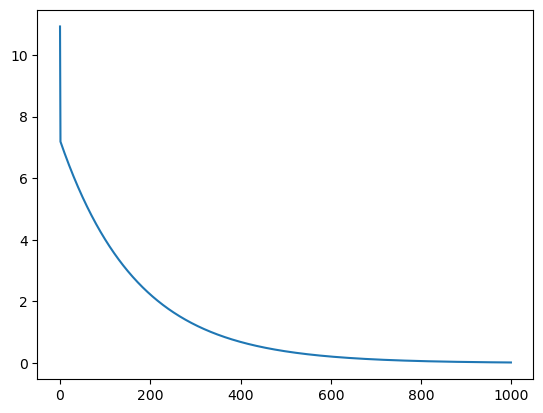

In [220]:
plt.plot(losses);

# Task 9: Predictions

In [221]:
model_untrained = Model(2)

x_test, y_test = generate_exampeles(500)
print(x_test.shape, y_test.shape)

(500, 2) (500, 1)


In [222]:
preds_untrained = model_untrained.forward_pass(x_test)
preds_trained = model.forward_pass(x_test)

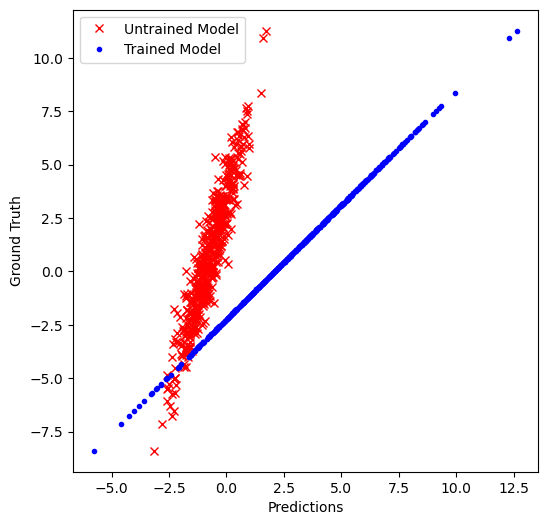

In [223]:
plt.figure(figsize=(6,6))
plt.plot(preds_untrained, y_test, 'rx', label='Untrained Model')
plt.plot(preds_trained, y_test, 'b.', label = 'Trained Model')
plt.legend()
plt.xlabel('Predictions')
plt.ylabel('Ground Truth')
plt.show()

#the trained more 